# Laboratorio 7: transformada rápida de Fourier

**Andrés Felipe Serrano Barrios**

Física Computacional I (0302151), grupo 001

Instituto de Física, Universidad de Antioquia

Semestre 2026-2, profesor Andrés Felipe Rivera Romero

---

# 1. Imagen

Foto de la pantalla del osciloscopio tomada en el taller de circuitos RC y RLC de Laboratorio Avanzado I, con
el circuito RLC serie alimentado a 200 kHz. El canal 1 (rojo) es el voltaje de entrada, el canal 2 (amarillo)
el voltaje en la resistencia, y la base de tiempo es de 2 µs por división.

Se recorta la zona de la cuadrícula, de $690\times510$ píxeles, y se promedian bloques de $3\times3$ píxeles,
lo que deja una malla de $M\times N=170\times230$. La rutina de la sección 3 hace $MN(M+N)$ productos (paso 6),
por eso la malla se mantiene pequeña. Las distancias se miden en píxeles de la foto, así que el lado de cada
punto de la malla es $\Delta=3$.

In [1]:
import io
import os
import tempfile
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy.fft import fft, fft2, fftfreq, fftshift, ifft2

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": False})

Foto: 900 x 677 píxeles
Malla: 170 x 230    lado de cada punto: 3 píxeles de la foto


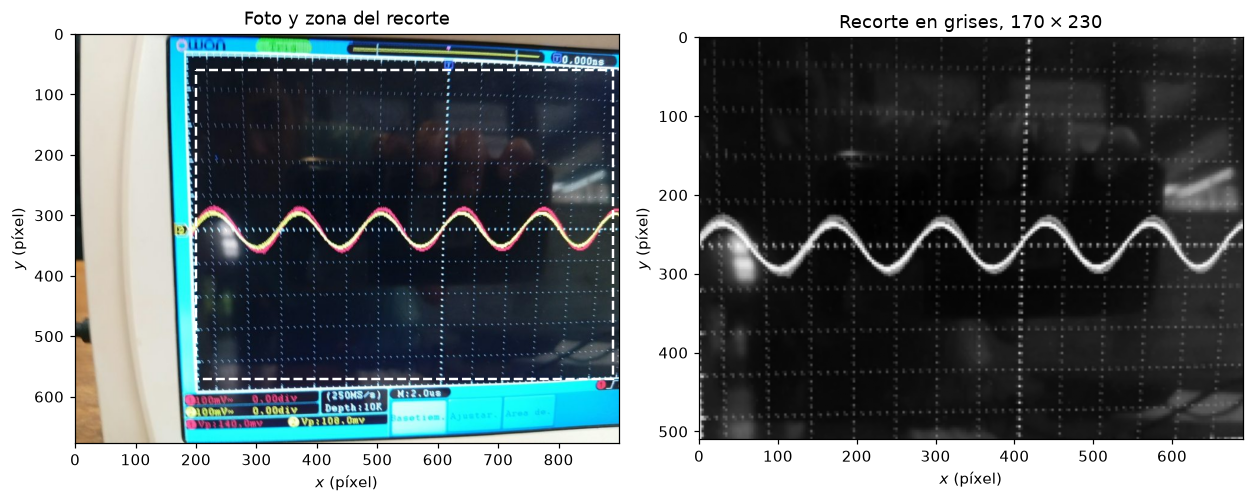

In [2]:
URL = "https://raw.githubusercontent.com/AndresFSerrano/Fisica_Computacional_1/main/Estudiantes/Serrano_4632/osciloscopio_rlc.jpg"
foto = Image.open(io.BytesIO(urllib.request.urlopen(URL).read()))
gris = foto.convert("L")

x0, y0, x1, y1, bloque = 200, 60, 890, 570, 3
imagen = np.asarray(gris.crop((x0, y0, x1, y1)).reduce(bloque), dtype=float)
M, N = imagen.shape
paso = bloque

print("Foto:", foto.size[0], "x", foto.size[1], "píxeles")
print("Malla:", M, "x", N, "   lado de cada punto:", paso, "píxeles de la foto")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4))
ax[0].imshow(foto)
ax[0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="white", linewidth=1.6,
                              linestyle="--"))
ax[0].set_title("Foto y zona del recorte")
ax[0].set_xlabel("$x$ (píxel)")
ax[0].set_ylabel("$y$ (píxel)")
ax[1].imshow(imagen, cmap="gray", extent=[0, N*paso, M*paso, 0])
ax[1].set_title(r"Recorte en grises, $170\times230$")
ax[1].set_xlabel("$x$ (píxel)")
ax[1].set_ylabel("$y$ (píxel)")
fig.tight_layout()
plt.show()

---

# 2. Transformada con scipy

**Paso 1. Transformada discreta.** Para una imagen de $M\times N$ puntos con valores $f_{mn}$ (fila $m$,
columna $n$), `fft2` calcula

$$F_{kl}=\sum_{m=0}^{M-1}\sum_{n=0}^{N-1}f_{mn}\,e^{-2\pi i\,(km/M+ln/N)},\qquad k=0,\dots,M-1,\quad
l=0,\dots,N-1.$$

**Paso 2. Frecuencias.** Las posiciones son $y_m=m\,\Delta$ y $x_n=n\,\Delta$. Con $v_k=\dfrac{k}{M\Delta}$ y
$u_l=\dfrac{l}{N\Delta}$:

$$\frac{km}{M}+\frac{ln}{N}=v_k\,y_m+u_l\,x_n.$$

Como $n$ es entero, $e^{-2\pi i\,(l-N)n/N}=e^{-2\pi i\,ln/N}\,e^{2\pi i\,n}=e^{-2\pi i\,ln/N}$, así que los
índices $l\ge N/2$ representan las frecuencias negativas $(l-N)/(N\Delta)$, y lo mismo con $k$. Ese es el orden
que devuelve `fftfreq`.

**Paso 3. Imagen periódica en $x$.** Si cada fila se repite cada $P$ columnas, $f_{m,n+P}=f_{mn}$, con $N$
múltiplo de $P$, el cambio $n\to n+P$ en la suma sobre $n$ da

$$\sum_{n}f_{mn}\,e^{-2\pi i\,ln/N}=\sum_{n}f_{m,n+P}\,e^{-2\pi i\,l(n+P)/N}
=e^{-2\pi i\,lP/N}\sum_{n}f_{mn}\,e^{-2\pi i\,ln/N}.$$

La suma solo puede ser distinta de cero si $e^{-2\pi i\,lP/N}=1$, es decir, si $lP/N$ es entero. Con
$T=P\Delta$, el espectro queda en las columnas

$$u_l=\frac{j}{T},\qquad j=0,1,2,\dots$$

Si el recorte no contiene un número entero de periodos, los picos caen en la columna más cercana, con un error
de hasta media separación entre columnas, $1/(2N\Delta)$.

En la foto se repiten dos cosas a lo largo de $x$: la traza, con el periodo $T$ de la señal, y los puntos de las
líneas horizontales de la cuadrícula, que van a cinco por división. Al sumar $|F_{kl}|$ sobre $k$, cada familia
de columnas queda como una serie de picos en $u$.

**Paso 4. Frecuencia de la señal.** Si el pico de la traza está en $l_t$ y el de los puntos en $l_p$,

$$T=\frac{N\Delta}{l_t},\qquad \text{div}=5\,\frac{N\Delta}{l_p},\qquad
\frac{T}{\text{div}}=\frac{l_p}{5\,l_t},\qquad f=\frac{1}{T}=\frac{5\,l_t}{l_p\,(2\ \mu\text{s})}.$$

Pico de la traza: l = 5   T = 138.0 píxeles
Pico de los puntos: l = 64   separación = 10.78 píxeles   división = 53.9 píxeles
Periodo: 2.56 divisiones = 5.12 µs
Frecuencia: 195.3 kHz, entre 175.8 y 214.8 kHz


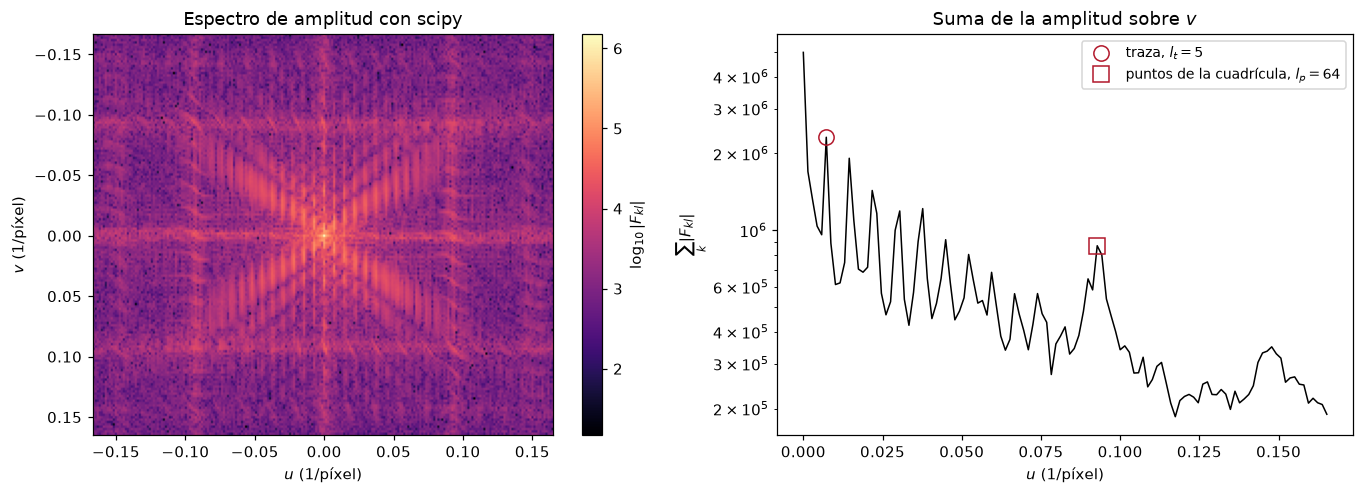

In [3]:
F = fft2(imagen)
u = fftfreq(N, paso)
v = fftfreq(M, paso)
amplitud = np.abs(F)

suma = np.zeros(N)
for l in range(N):
    for k in range(M):
        suma[l] = suma[l] + amplitud[k, l]

l_t = 1
for l in range(1, N//2):
    if suma[l] > suma[l_t]:
        l_t = l

l_p = 0
for l in range(1, N//2):
    if 1.0/u[l] < 20 and (l_p == 0 or suma[l] > suma[l_p]):
        l_p = l

T_div = l_p/(5*l_t)
f_khz = 1.0/(T_div*2e-6)/1e3
f_min = 1.0/(l_p/(5*(l_t - 0.5))*2e-6)/1e3
f_max = 1.0/(l_p/(5*(l_t + 0.5))*2e-6)/1e3

print("Pico de la traza: l =", l_t, "  T =", round(1.0/u[l_t], 1), "píxeles")
print("Pico de los puntos: l =", l_p, "  separación =", round(1.0/u[l_p], 2), "píxeles   división =",
      round(5.0/u[l_p], 1), "píxeles")
print("Periodo:", round(T_div, 3), "divisiones =", round(T_div*2, 2), "µs")
print("Frecuencia:", round(f_khz, 1), "kHz, entre", round(f_min, 1), "y", round(f_max, 1), "kHz")

desplazada_u = fftshift(u)
desplazada_v = fftshift(v)
borde = [desplazada_u[0], desplazada_u[N - 1], desplazada_v[M - 1], desplazada_v[0]]

positivas = []
valores = []
for l in range(N//2):
    positivas.append(u[l])
    valores.append(suma[l])

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))
mapa = ax[0].imshow(np.log10(fftshift(amplitud)), cmap="magma", extent=borde, aspect="auto")
ax[0].set_xlabel("$u$ (1/píxel)")
ax[0].set_ylabel("$v$ (1/píxel)")
ax[0].set_title("Espectro de amplitud con scipy")
fig.colorbar(mapa, ax=ax[0], label=r"$\log_{10}|F_{kl}|$")
ax[1].semilogy(positivas, valores, color="black", linewidth=1.0)
ax[1].plot(u[l_t], suma[l_t], "o", color="#b2182b", fillstyle="none", markersize=10,
           label=f"traza, $l_t={l_t}$")
ax[1].plot(u[l_p], suma[l_p], "s", color="#b2182b", fillstyle="none", markersize=10,
           label=f"puntos de la cuadrícula, $l_p={l_p}$")
ax[1].set_xlabel("$u$ (1/píxel)")
ax[1].set_ylabel(r"$\sum_k |F_{kl}|$")
ax[1].set_title("Suma de la amplitud sobre $v$")
ax[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

En el espectro, la traza deja columnas brillantes igualmente espaciadas, y en la suma sobre $v$ aparecen como
una serie de picos en $u=j/T$. El más alto es el primero, en $l_t=5$, que corresponde a $T=138$ píxeles. Los
puntos de la cuadrícula dan el pico en $l_p=64$: 10,8 píxeles entre puntos y 53,9 píxeles por división. Con el
paso 4, el periodo de la señal es de 2,56 divisiones, es decir 5,12 µs, y la frecuencia es de 195 kHz. Por la
separación entre columnas (paso 3), queda entre 176 y 215 kHz. El generador estaba en 200 kHz.

---

# 3. Rutina de clase modificada

La rutina `FT(x,y)` de la [sesión](https://github.com/anferivera/Fisica_Computacional_1/blob/main/Sesiones/Fourier/2_Fourier_transform.ipynb) interpola los datos con `interp1d` y calcula la
integral con `quad` en las frecuencias de `np.linspace(0.1, 1, 100)`.

**Paso 5. De la integral a la suma.** En dos dimensiones y sin el factor de normalización de `g` (ver los
cambios al final de esta sección), la transformada es

$$F(u,v)=\iint f(x,y)\,e^{-2\pi i\,(ux+vy)}\,dx\,dy.$$

La imagen ya está muestreada en una malla uniforme, así que la integral se aproxima con la regla del
rectángulo sobre los valores de los puntos, sin interpolar:

$$F(u,v)\approx\Delta^2\sum_{m=0}^{M-1}\sum_{n=0}^{N-1}f_{mn}\,e^{-2\pi i\,(u\,x_n+v\,y_m)}.$$

En las frecuencias $u_l$ y $v_k$ del paso 2, la suma es la del paso 1:

$$F(u_l,v_k)\approx\Delta^2\,F_{kl}.$$

**Paso 6. Separabilidad.** Como $e^{-2\pi i\,(km/M+ln/N)}=e^{-2\pi i\,km/M}\,e^{-2\pi i\,ln/N}$,

$$\Delta^2F_{kl}=\Delta\sum_{m}e^{-2\pi i\,km/M}\,G_{ml},\qquad
G_{ml}=\Delta\sum_{n}f_{mn}\,e^{-2\pi i\,ln/N}.$$

$G_{ml}$ es la transformada en una dimensión de la fila $m$. La transformada en dos dimensiones sale de
aplicar `FT` a cada fila de la imagen y luego a cada columna de $G$. Las $M$ filas cuestan $N^2$ productos cada
una y las $N$ columnas $M^2$ cada una, en total $MN(M+N)$.

Cambios respecto a `FT(x,y)` de la sesión:

- Sin `interp1d` ni `quad`: la integral es la suma del paso 5.
- Las frecuencias entran como argumento `w`. Si no se dan, son las de la malla (paso 2), las mismas de
  `fftfreq`, para comparar punto a punto con scipy.
- `g` no lleva el factor $1/(2\pi)$, porque scipy no normaliza la transformada directa.
- `y` puede ser complejo, lo que permite aplicar `FT` a las columnas de $G$.

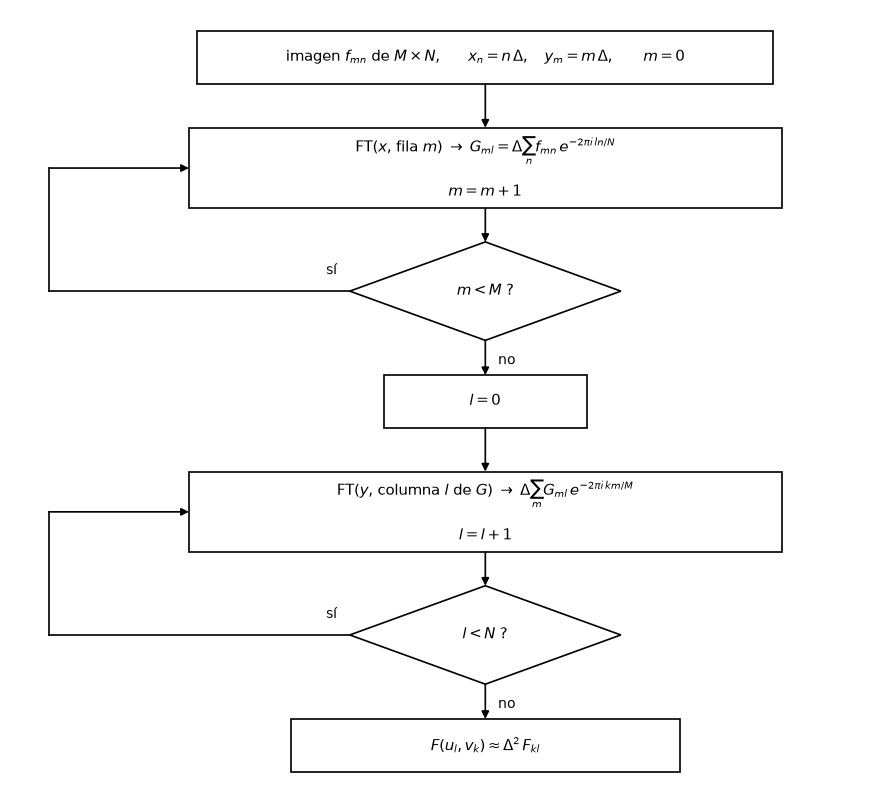

In [4]:
def g(t, w):
    return np.exp(-1j*2*np.pi*w*t)


def FT(x, y, w=None):
    """Transformada de Fourier de los datos (x, y) por suma directa, en las frecuencias w o en las de la malla."""
    n = len(x)
    dx = x[1] - x[0]

    if w is None:
        w = []
        for k in range(n):
            if k < (n + 1)//2:
                w.append(k/(n*dx))
            else:
                w.append((k - n)/(n*dx))

    df = []
    for i in range(len(w)):
        suma = 0.0
        for m in range(n):
            suma = suma + y[m]*g(x[m], w[i])
        ARew = suma.real*dx
        AImw = suma.imag*dx
        AMP = np.sqrt(ARew**2 + AImw**2)
        ANG = np.arctan2(AImw, ARew)
        df.append([w[i], ARew, AImw, AMP, ANG])

    df = pd.DataFrame(df, columns=["w", "ReTw", "ImTw", "AMP", "ANG"])
    return df

In [5]:
pos_x = np.zeros(N)
for n in range(N):
    pos_x[n] = n*paso

pos_y = np.zeros(M)
for m in range(M):
    pos_y[m] = m*paso

G = np.zeros((M, N), dtype=complex)
for m in range(M):
    fila = np.zeros(N)
    for n in range(N):
        fila[n] = imagen[m, n]
    df = FT(pos_x, fila)
    for l in range(N):
        G[m, l] = df.ReTw[l] + 1j*df.ImTw[l]

F_mano = np.zeros((M, N), dtype=complex)
for l in range(N):
    columna = np.zeros(M, dtype=complex)
    for m in range(M):
        columna[m] = G[m, l]
    df = FT(pos_y, columna)
    for k in range(M):
        F_mano[k, l] = df.ReTw[k] + 1j*df.ImTw[k]

maximo = 0.0
diferencia = 0.0
for k in range(M):
    for l in range(N):
        referencia = paso**2*F[k, l]
        if abs(referencia) > maximo:
            maximo = abs(referencia)
        if abs(F_mano[k, l] - referencia) > diferencia:
            diferencia = abs(F_mano[k, l] - referencia)

print("Máximo de |Δ² F_kl| con scipy:", maximo)
print("Diferencia máxima con FT:     ", diferencia)
print("Diferencia relativa:          ", diferencia/maximo)

Máximo de |Δ² F_kl| con scipy: 13547439.0
Diferencia máxima con FT:      6.4408276571082e-08
Diferencia relativa:           4.754276920610751e-15


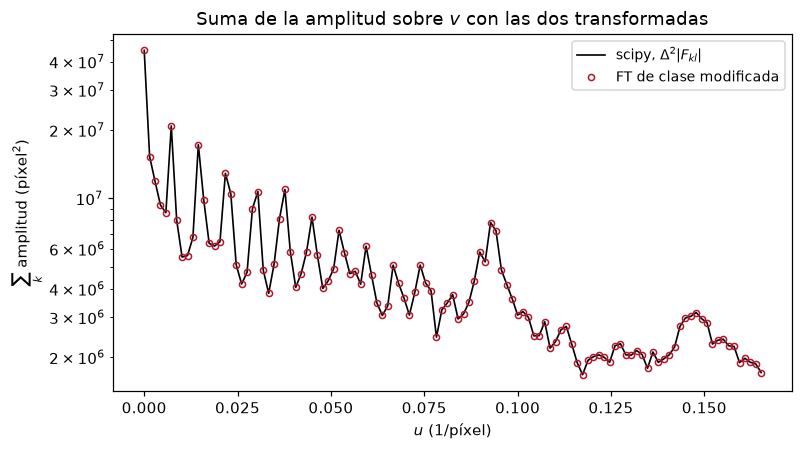

In [6]:
con_scipy = []
con_FT = []
for l in range(N//2):
    total_scipy = 0.0
    total_FT = 0.0
    for k in range(M):
        total_scipy = total_scipy + abs(paso**2*F[k, l])
        total_FT = total_FT + abs(F_mano[k, l])
    con_scipy.append(total_scipy)
    con_FT.append(total_FT)

fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.semilogy(positivas, con_scipy, color="black", linewidth=1.1, label="scipy, $\\Delta^2|F_{kl}|$")
ax.semilogy(positivas, con_FT, color="#b2182b", marker="o", markersize=4, linestyle="none",
            fillstyle="none", label="FT de clase modificada")
ax.set_xlabel("$u$ (1/píxel)")
ax.set_ylabel(r"$\sum_k$ amplitud (píxel$^2$)")
ax.set_title("Suma de la amplitud sobre $v$ con las dos transformadas")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

Se obtiene el mismo resultado. La rutina modificada reproduce la transformada de scipy en los $170\times230$
puntos con una diferencia relativa máxima del orden de $10^{-15}$, que es el nivel del redondeo, y la suma sobre
$v$ muestra los mismos picos con las mismas alturas.

---

# 4. Transformada inversa

**Paso 7. Suma geométrica.** Para un entero $p$ que no es múltiplo de $N$, $r=e^{2\pi i\,p/N}\neq1$ y
$r^N=e^{2\pi i\,p}=1$, así que

$$\sum_{l=0}^{N-1}r^l=\frac{1-r^N}{1-r}=0.$$

Si $p$ es múltiplo de $N$, cada término vale 1 y la suma es $N$. Con $0\le n,n'\le N-1$, la diferencia
$n-n'$ solo es múltiplo de $N$ cuando $n=n'$:

$$\sum_{l=0}^{N-1}e^{2\pi i\,l(n-n')/N}=N\,\delta_{nn'},$$

y lo mismo con $M$ en la otra dirección.

**Paso 8. Fórmula inversa.** Se multiplica $F_{kl}$ del paso 1 por $e^{2\pi i\,(km'/M+ln'/N)}$ y se suma en
$k$ y $l$:

$$\sum_{k}\sum_{l}F_{kl}\,e^{2\pi i\,(km'/M+ln'/N)}=\sum_{m}\sum_{n}f_{mn}\,(M\,\delta_{mm'})(N\,\delta_{nn'})
=MN\,f_{m'n'},$$

$$f_{mn}=\frac{1}{MN}\sum_{k=0}^{M-1}\sum_{l=0}^{N-1}F_{kl}\,e^{2\pi i\,(km/M+ln/N)},$$

que es lo que calcula `ifft2`. La reconstrucción no pierde información: solo puede diferir de la original por
redondeo.

Máximo de la parte imaginaria:             3.751338205608042e-14
Diferencia máxima con la original (0-255): 1.7053025658242404e-13


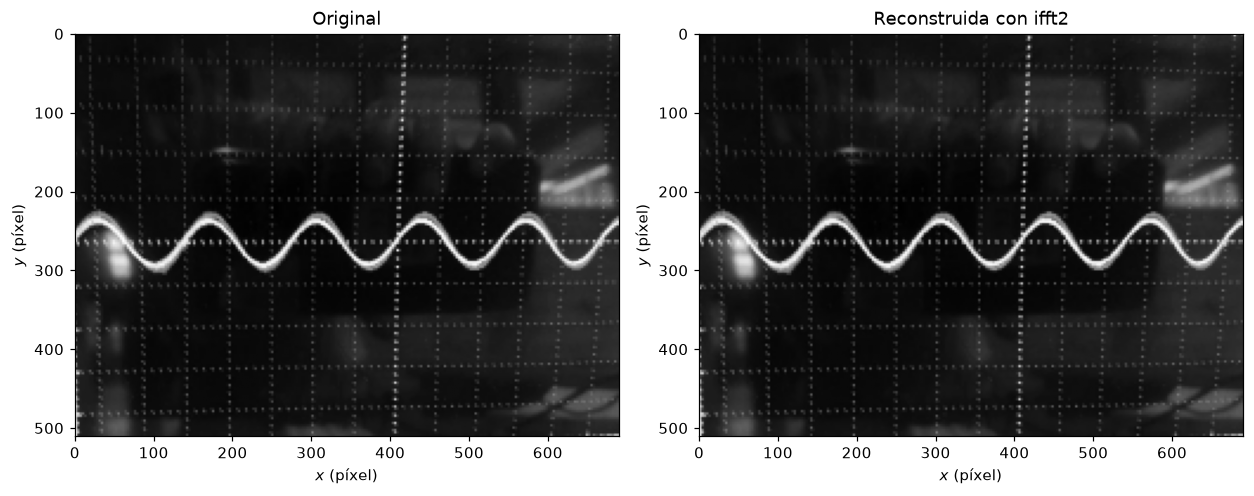

In [7]:
reconstruida = ifft2(F)

parte_imaginaria = 0.0
diferencia = 0.0
for m in range(M):
    for n in range(N):
        if abs(reconstruida[m, n].imag) > parte_imaginaria:
            parte_imaginaria = abs(reconstruida[m, n].imag)
        if abs(reconstruida[m, n].real - imagen[m, n]) > diferencia:
            diferencia = abs(reconstruida[m, n].real - imagen[m, n])

print("Máximo de la parte imaginaria:            ", parte_imaginaria)
print("Diferencia máxima con la original (0-255):", diferencia)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4))
ax[0].imshow(imagen, cmap="gray", extent=[0, N*paso, M*paso, 0])
ax[0].set_title("Original")
ax[1].imshow(reconstruida.real, cmap="gray", extent=[0, N*paso, M*paso, 0])
ax[1].set_title("Reconstruida con ifft2")
for i in range(2):
    ax[i].set_xlabel("$x$ (píxel)")
    ax[i].set_ylabel("$y$ (píxel)")
fig.tight_layout()
plt.show()

La imagen reconstruida coincide con la original: en una escala de grises de 0 a 255, la diferencia máxima y
la parte imaginaria son del orden de $10^{-13}$, que es el nivel del redondeo, como anticipa el paso 8.

---

# 5. Acorde de Do mayor

El archivo [`Nota_CM_piano.mp3`](https://github.com/anferivera/Fisica_Computacional_1/blob/main/Sesiones/Fourier/Nota_CM_piano.mp3) se carga con `librosa`, como en la
[sesión](https://github.com/anferivera/Fisica_Computacional_1/blob/main/Sesiones/Fourier/2_Fourier_transform.ipynb). Se calcula su transformada con scipy y NumPy (punto 1 del Example 1) y con la
rutina `FT` de la sección 3 (punto 2), y se comparan.

Se toma un tramo de 0,5 s que empieza en 0,3 s, después del ataque de las notas (el máximo de la señal está en
0,29 s). La separación entre frecuencias
de la transformada discreta es $1/(n\,\Delta t)=2$ Hz, suficiente para separar las tres notas. Como `FT` hace $n$
productos por frecuencia, se evalúa solo entre 200 y 450 Hz.

**Paso 9. Transformada en una dimensión.** Con una sola variable y $t_m=m\,\Delta t$, el paso 5 da

$$F(f)\approx\Delta t\sum_{m=0}^{n-1}s_m\,e^{-2\pi i\,f\,t_m}.$$

En las frecuencias $f_k=k/(n\,\Delta t)$ de `fftfreq`, el exponente es $-2\pi i\,km/n$ y la suma es la salida
$S_k$ de `fft`:

$$F(f_k)\approx\Delta t\,S_k.$$

**Paso 10. Frecuencias de las notas.** En la afinación temperada, la octava, que duplica la frecuencia, se
divide en 12 semitonos iguales, así que cada semitono multiplica la frecuencia por $2^{1/12}$. Con La4 = 440 Hz
como referencia, una nota que está $s$ semitonos por encima de La4 suena a

$$f_s=440\cdot2^{s/12}\ \text{Hz}.$$

Do4, Mi4 y Sol4 están 9, 5 y 2 semitonos por debajo de La4, es decir $s=-9,-5,-2$.

Frecuencia de muestreo: 44100 Hz   duración: 3.45 s
Tramo: 22050 muestras desde 0.3 s   separación entre frecuencias: 2.0 Hz


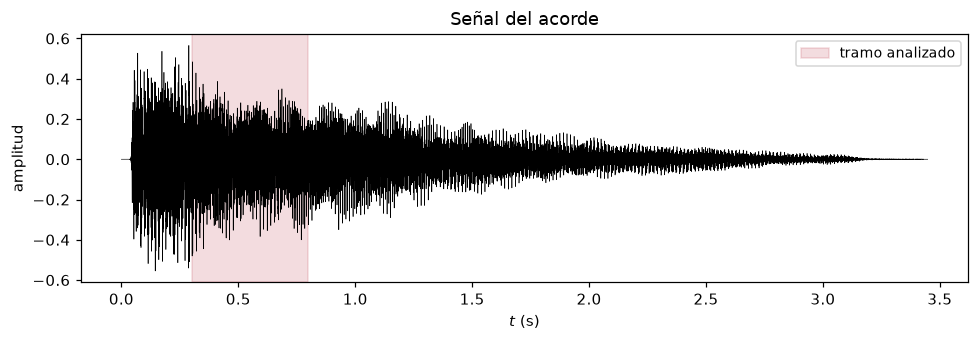

In [8]:
import librosa

URL_ACORDE = "https://raw.githubusercontent.com/anferivera/Fisica_Computacional_1/main/Sesiones/Fourier/Nota_CM_piano.mp3"
ruta = os.path.join(tempfile.gettempdir(), "Nota_CM_piano.mp3")
urllib.request.urlretrieve(URL_ACORDE, ruta)
sonido, sr = librosa.load(ruta, sr=None)

dt = 1.0/sr
inicio = int(0.3*sr)
n = int(0.5*sr)

tiempo = np.zeros(n)
tramo = np.zeros(n)
for m in range(n):
    tiempo[m] = m*dt
    tramo[m] = sonido[inicio + m]

t_total = np.zeros(len(sonido))
for m in range(len(sonido)):
    t_total[m] = m*dt

print("Frecuencia de muestreo:", sr, "Hz   duración:", round(len(sonido)*dt, 2), "s")
print("Tramo:", n, "muestras desde", round(inicio*dt, 2), "s   separación entre frecuencias:", 1.0/(n*dt), "Hz")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(t_total, sonido, color="black", linewidth=0.4)
ax.axvspan(inicio*dt, (inicio + n)*dt, color="#b2182b", alpha=0.15, label="tramo analizado")
ax.set_xlabel("$t$ (s)")
ax.set_ylabel("amplitud")
ax.set_title("Señal del acorde")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

Diferencia relativa máxima entre NumPy y scipy: 1.599553689286018e-16
Frecuencias evaluadas con FT: 126 entre 200.0 y 450.0 Hz
Diferencia relativa máxima entre FT y scipy: 4.803092456182907e-14

Do4 261.6 Hz   pico con scipy: 262.0 Hz   pico con FT: 262.0 Hz
Mi4 329.6 Hz   pico con scipy: 330.0 Hz   pico con FT: 330.0 Hz
Sol4 392.0 Hz   pico con scipy: 392.0 Hz   pico con FT: 392.0 Hz


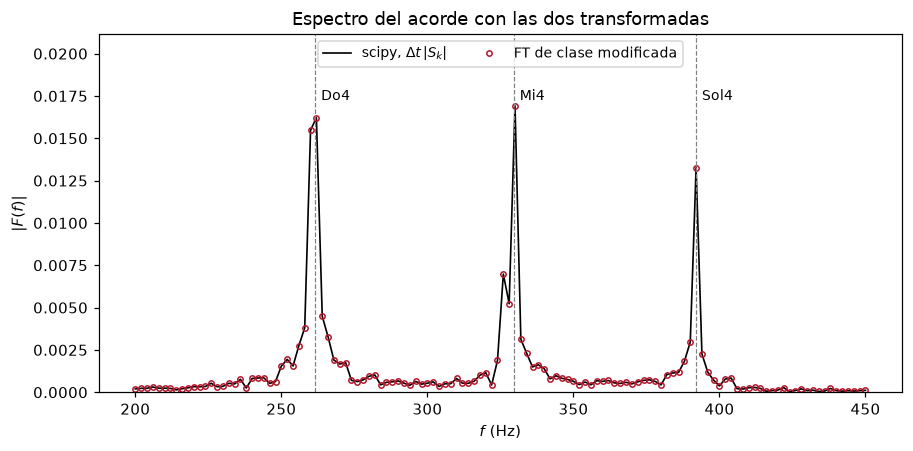

In [9]:
S = fft(tramo)
S_numpy = np.fft.fft(tramo)
frec = fftfreq(n, dt)

maximo_S = 0.0
diferencia_numpy = 0.0
for k in range(n):
    if abs(S[k]) > maximo_S:
        maximo_S = abs(S[k])
    if abs(S_numpy[k] - S[k]) > diferencia_numpy:
        diferencia_numpy = abs(S_numpy[k] - S[k])

indices = []
w = []
for k in range(n//2):
    if frec[k] >= 200 and frec[k] <= 450:
        indices.append(k)
        w.append(frec[k])

df = FT(tiempo, tramo, w)

amp_scipy = []
maximo = 0.0
diferencia = 0.0
for i in range(len(w)):
    referencia = dt*S[indices[i]]
    amp_scipy.append(abs(referencia))
    if abs(referencia) > maximo:
        maximo = abs(referencia)
    valor = df.ReTw[i] + 1j*df.ImTw[i]
    if abs(valor - referencia) > diferencia:
        diferencia = abs(valor - referencia)

print("Diferencia relativa máxima entre NumPy y scipy:", diferencia_numpy/maximo_S)
print("Frecuencias evaluadas con FT:", len(w), "entre", w[0], "y", w[len(w) - 1], "Hz")
print("Diferencia relativa máxima entre FT y scipy:", diferencia/maximo)
print()

notas = ["Do4", "Mi4", "Sol4"]
semitonos = [-9, -5, -2]
f_notas = []
for j in range(3):
    f_nota = 440*2**(semitonos[j]/12)
    f_notas.append(f_nota)
    i_scipy = -1
    i_FT = -1
    for i in range(len(w)):
        if abs(w[i] - f_nota) < 6:
            if i_scipy < 0 or amp_scipy[i] > amp_scipy[i_scipy]:
                i_scipy = i
            if i_FT < 0 or df.AMP[i] > df.AMP[i_FT]:
                i_FT = i
    print(notas[j], round(f_nota, 1), "Hz   pico con scipy:", w[i_scipy], "Hz   pico con FT:", df.w[i_FT], "Hz")

fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.plot(w, amp_scipy, color="black", linewidth=1.1, label="scipy, $\\Delta t\\,|S_k|$")
ax.plot(df.w, df.AMP, color="#b2182b", marker="o", markersize=3.5, linestyle="none", fillstyle="none",
        label="FT de clase modificada")
alto = max(amp_scipy)
for j in range(3):
    ax.axvline(f_notas[j], color="gray", linestyle="--", linewidth=0.8)
    ax.text(f_notas[j] + 2, 1.02*alto, notas[j], fontsize=9)
ax.set_ylim(0, 1.25*alto)
ax.set_xlabel("$f$ (Hz)")
ax.set_ylabel("$|F(f)|$")
ax.set_title("Espectro del acorde con las dos transformadas")
ax.legend(fontsize=9, loc="upper center", ncol=2)
fig.tight_layout()
plt.show()

Se obtiene el mismo resultado. NumPy y scipy dan la misma transformada, con una diferencia relativa del orden de
$10^{-16}$. En las 126 frecuencias evaluadas, la rutina modificada coincide con
$\Delta t\,S_k$ con una diferencia relativa máxima del orden de $10^{-14}$, que es el nivel del redondeo, como
anticipa el paso 9. Los tres picos caen en 262, 330 y 392 Hz, que coinciden con Do4, Mi4 y Sol4 (261,6, 329,6 y
392,0 Hz) dentro de la separación de 2 Hz entre frecuencias.

---

## Referencias

- Material del curso: [`Sesiones/Fourier/2_Fourier_transform.ipynb`](https://github.com/anferivera/Fisica_Computacional_1/blob/main/Sesiones/Fourier/2_Fourier_transform.ipynb), para la rutina
  `FT(x,y)` y la transformada con scipy.
- Documentación de [`scipy.fft`](https://docs.scipy.org/doc/scipy/reference/fft.html): `fft`, `fft2`,
  `ifft2`, `fftfreq` y `fftshift`, y de [`numpy.fft`](https://numpy.org/doc/stable/reference/routines.fft.html):
  `fft`.
- La foto y la frecuencia del generador son del taller de circuitos RC y RLC de Laboratorio Avanzado I
  (0302711), semestre 2026-2.
- El acorde es [`Sesiones/Fourier/Nota_CM_piano.mp3`](https://github.com/anferivera/Fisica_Computacional_1/blob/main/Sesiones/Fourier/Nota_CM_piano.mp3), del material del curso.
- ISO 16:1975, *Acoustics — Standard tuning frequency (Standard musical pitch)*, para La4 = 440 Hz.